###### **Extracting Information from Legal Documents Using RAG**

## **Objective**

The main objective of this assignment is to process and analyse a collection text files containing legal agreements (e.g., NDAs) to prepare them for implementing a **Retrieval-Augmented Generation (RAG)** system. This involves:

* Understand the Cleaned Data : Gain a comprehensive understanding of the structure, content, and context of the cleaned dataset.
* Perform Exploratory Analysis : Conduct bivariate and multivariate analyses to uncover relationships and trends within the cleaned data.
* Create Visualisations : Develop meaningful visualisations to support the analysis and make findings interpretable.
* Derive Insights and Conclusions : Extract valuable insights from the cleaned data and provide clear, actionable conclusions.
* Document the Process : Provide a detailed description of the data, its attributes, and the steps taken during the analysis for reproducibility and clarity.

The ultimate goal is to transform the raw text data into a clean, structured, and analysable format that can be effectively used to build and train a RAG system for tasks like information retrieval, question-answering, and knowledge extraction related to legal agreements.

### **Business Value**  


The project aims to leverage RAG to enhance legal document processing for businesses, law firms, and regulatory bodies. The key business objectives include:

* Faster Legal Research: <br> Reduce the time lawyers and compliance officers spend searching for relevant case laws, precedents, statutes, or contract clauses.
* Improved Contract Analysis: <br> Automatically extract key terms, obligations, and risks from lengthy contracts.
* Regulatory Compliance Monitoring: <br> Help businesses stay updated with legal and regulatory changes by retrieving relevant legal updates.
* Enhanced Decision-Making: <br> Provide accurate and context-aware legal insights to assist in risk assessment and legal strategy.


**Use Cases**
* Legal Chatbots
* Contract Review Automation
* Tracking Regulatory Changes and Compliance Monitoring
* Case Law Analysis of past judgments
* Due Diligence & Risk Assessment

## **1. Data Loading, Preparation and Analysis** <font color=red> [20 marks] </font><br>

### **1.1 Data Understanding**

The dataset contains legal documents and contracts collected from various sources. The documents are present as text files (`.txt`) in the *corpus* folder.

There are four types of documents in the *courpus* folder, divided into four subfolders.
- `contractnli`: contains various non-disclosure and confidentiality agreements
- `cuad`: contains contracts with annotated legal clauses
- `maud`: contains various merger/acquisition contracts and agreements
- `privacy_qa`: a question-answering dataset containing privacy policies

The dataset also contains evaluation files in JSON format in the *benchmark* folder. The files contain the questions and their answers, along with sources. For the above folders, there is a `json` file: `contractnli.json`, `cuad.json`, `maud.json`. The file structure is as follows:

```
{
    "tests": [
        {
            "query": <question1>,
            "snippets": [{
                    "file_path": <source_file1>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 1>
                },
                {
                    "file_path": <source_file2>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 2>
                }, ....
            ]
        },
        {
            "query": <question2>,
            "snippets": [{<answer context for que 2>}]
        },
        ... <more queries>
    ]
}
```

### **1.2 Load and Preprocess the data** <font color=red> [5 marks] </font><br>

#### Loading libraries

In [2]:
import torch
import os

torch.set_num_threads(12)
os.environ["OMP_NUM_THREADS"] = "12"
os.environ["MKL_NUM_THREADS"] = "12"

print("PyTorch threads:", torch.get_num_threads())

PyTorch threads: 12


In [3]:
# !pip install -U ragas langchain langchain-core langchain-community langchain-ollama langchain-huggingface langchain-chroma

In [4]:
# !pip install -U langchain-ollama

In [5]:
# !pip install -U ragas langchain langchain-community langchain-core

In [6]:
# %pip install -qU  langchain langchain-huggingface sentence_transformers

In [7]:
# !pip install -U langchain-huggingface huggingface_hub

In [8]:
# !pip install -U spacy
# !python -m spacy download en_core_web_sm

In [9]:
## The following libraries might be useful
# !pip install -q langchain-openai
# !pip install -U -q langchain-community
# !pip install -U -q langchain-chroma
# !pip install -U -q datasets
# !pip install -U -q ragas
# !pip install -U -q rouge_score
# !pip install langchain-text-splitters

In [10]:
!pip install langchain-text-splitters


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [11]:
# Import essential libraries
import os
import re
import json
from dotenv import load_dotenv
from openai import OpenAI
import pandas as pd
import numpy as np
from langchain_community.document_loaders import DirectoryLoader, TextLoader

/tmp/ipykernel_646/1341017481.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader, TextLoader
/home/piyush0912/pyspark-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **1.2.1** <font color=red> [3 marks] </font>
Load all `.txt` files from the folders.

You can utilise document loaders from the options provided by the LangChain community.

Optionally, you can also read the files manually, while ensuring proper handling of encoding issues (e.g., utf-8, latin1). In such case, also store the file content along with metadata (e.g., file name, directory path) for traceability.

In [12]:
# Load the files as documents

loader = DirectoryLoader(
    'rag_legal/corpus',          # root folder
    glob="**/*.txt",              # ** = recurse into all subfolders
    loader_cls=TextLoader,
    loader_kwargs={"autodetect_encoding": True},  # handles utf-8/latin1 issues
    show_progress=True,
    use_multithreading=True,
)

documents = loader.load()
for doc in documents:
    path = os.path.normpath(doc.metadata["source"])
    doc.metadata["category"] = os.path.basename(os.path.dirname(path))
    doc.metadata["filename"] = os.path.basename(path)
    
print(len(documents))
print(documents[0].metadata)   # {'source': 'rag_legal/corpus/contractnli/xyz.txt'}

100%|████████████████████████████████████████████████████████████████████████████████| 233/233 [00:00<00:00, 699.92it/s]

233
{'source': 'rag_legal/corpus/cuad/AULAMERICANUNITTRUST_04_24_2020-EX-99.8.77-SERVICING AGREEMENT.txt', 'category': 'cuad', 'filename': 'AULAMERICANUNITTRUST_04_24_2020-EX-99.8.77-SERVICING AGREEMENT.txt'}


#### **1.2.2** <font color=red> [2 marks] </font>
Preprocess the text data to remove noise and prepare it for analysis.

Remove special characters, extra whitespace, and irrelevant content such as email and telephone contact info.
Normalise text (e.g., convert to lowercase, remove stop words).
Handle missing or corrupted data by logging errors and skipping problematic files.

In [13]:
# Clean and preprocess the data
# creating cope of documents for analysis as all of this preprocessing might break my RAG pipeline
import copy
doc_analysis = copy.deepcopy(documents)

# creating a df to get preview of documents
df = pd.DataFrame([
    {
        "source": doc.metadata.get("source"),
        "category": doc.metadata.get("category"),
        "length": len(doc.page_content),
        "preview": doc.page_content[:150]
    }
    for doc in doc_analysis
])
df.head(10)

,source,category,length,preview
0,rag_legal/corpus/cuad/AULAMERICANUNITTRUST_04_...,cuad,36019,Exhibit 8.77 SERVICING AGREEMENT NATIONWIDE MU...
1,rag_legal/corpus/cuad/ASHWORTHINC_01_29_1999-E...,cuad,24999,EXHIBIT 10(d)\n\nPROMOTION AGREEMENT ...
2,rag_legal/corpus/cuad/ArmstrongFlooringInc_201...,cuad,56858,Exhibit 10.2\n\nExecution Version\n\nINTELLECT...
3,rag_legal/corpus/cuad/AURASYSTEMSINC_06_16_201...,cuad,45033,STRATEGIC ALLIANCE AGREEMENT This STRATEGIC...
4,"rag_legal/corpus/cuad/ARMSTRONGFLOORING,INC_01...",cuad,69759,Exhibit 10.2\n\nExecution Version\n\nINTELLECT...
5,"rag_legal/corpus/cuad/ADUROBIOTECH,INC_06_02_2...",cuad,12020,Exhibit 10.7\n\nCONSULTING AGREEMENT\n\nAduro ...
6,rag_legal/corpus/cuad/AlliedEsportsEntertainme...,cuad,37796,Exhibit 10.34 EVENT SPONSORSHIP AGREEMENT This...
7,"rag_legal/corpus/cuad/ADUROBIOTECH,INC_06_02_2...",cuad,12020,Exhibit 10.7\n\nCONSULTING AGREEMENT\n\nAduro ...
8,rag_legal/corpus/cuad/ArcGroupInc_20171211_8-K...,cuad,16773,Exhibit 10.1 JACKSONVILLE JAGUARS SPONSORSHI...
9,rag_legal/corpus/cuad/ArcaUsTreasuryFund_20200...,cuad,15318,Exhibit 99(k)(5) FORM OF BLOCKCHAIN ADMINISTRA...


### Note on doc_analysis

A deepcopy of documents was created as doc_analysis, kept separate for EDA (word frequency, TF-IDF) where aggressive cleaning (lowercasing, stopword removal) is useful. The original documents was kept lightly cleaned and preserved for chunking/embedding, since legal text relies on case (e.g., "Confidential Information") and negation words (e.g., "shall not") for meaning — aggressive cleaning here would distort retrieval and generation. A deep copy (not a plain assignment) was used so edits to one wouldn't silently affect the other.

In [14]:
# this function is for analysis only
def clean_text(text: str) -> str:
    # 1. Remove email addresses
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    
    # 2. Remove phone numbers
    text = re.sub(r'(\+?\d{1,3}[\s.-]?)?\(?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}', '', text)
    
    # 3. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 4. Normalize line endings and page-break artifacts FIRST
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\x0c", "\n")
    
    # 5. Remove lines that are just a page number
    text = re.sub(r"\n\s*\d{1,4}\s*\n", "\n", text)
    
    # 6. Collapse 3+ newlines to a paragraph break
    text = re.sub(r"\n{3,}", "\n\n", text)
    
    # 7. Remove special characters (keep basic punctuation + newlines)
    text = re.sub(r'[^a-zA-Z0-9.,;:()\-\s]', '', text)
    
    # 8. Collapse spaces/tabs (but preserve newlines)
    text = re.sub(r"[ \t]{2,}", " ", text)
    
    return text.strip()

In [15]:
# this is for preprocessing of main document

def clean_text_light(text: str) -> str:
    # 1. Remove email addresses
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    
    # 2. Remove phone numbers
    text = re.sub(r'(\+?\d{1,3}[\s.-]?)?\(?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}', '', text)
    
    # 3. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 4. Normalize line endings and page-break artifacts
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\x0c", "\n")
    
    # 5. Remove lines that are just a page number
    text = re.sub(r"\n\s*\d{1,4}\s*\n", "\n", text)
    
    # 6. Collapse 3+ newlines to a paragraph break
    text = re.sub(r"\n{3,}", "\n\n", text)
    
    # 7. Remove genuinely junk characters only — much narrower whitelist removal
    #    Keep letters (both cases), numbers, all standard punctuation, currency symbols, and whitespace
    text = re.sub(r'[^a-zA-Z0-9.,;:()\-\'\"%$&/\s]', '', text)
    
    # 8. Collapse repeated spaces/tabs (preserve newlines/paragraphs)
    text = re.sub(r"[ \t]{2,}", " ", text)
    
    return text.strip()

### Why two versions of clean_text

clean_text (aggressive) and clean_text_light were created for the same reason doc_analysis and documents were split: EDA and the RAG pipeline need different levels of normalization. clean_text lowercases and removes stopwords — good for word-frequency counts and TF-IDF similarity, where filler words would otherwise dominate. clean_text_light skips both, preserving case and full grammar (e.g., "shall not," "Confidential Information") since these carry legal meaning that embeddings and generation depend on. Applying the aggressive version to the RAG pipeline would distort retrieval and could even flip a clause's meaning.

In [16]:
import spacy

nlp = nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "lemmatizer", "tagger"])

def remove_stopwords_spacy(text):
    doc = nlp(text)
    filtered = [token.text for token in doc if not token.is_stop]
    return " ".join(filtered)

In [17]:
for doc in doc_analysis:
    doc.page_content = doc.page_content.lower()
    doc.page_content = " ".join(doc.page_content.split())
    doc.page_content = clean_text(doc.page_content)
    doc.page_content = remove_stopwords_spacy(doc.page_content)

In [18]:
doc_analysis[0].page_content[:150]

'exhibit 8.77 servicing agreement nationwide mutual funds agreement , day , 20 nationwide fund management llc ( nationwide ) , behalf nationwide mutual'

### **1.3 Exploratory Data Analysis** <font color=red> [10 marks] </font><br>

#### **1.3.1** <font color=red> [2 marks] </font>
Calculate the average, maximum and minimum document length.

In [19]:
# Calculate the average, maximum and minimum document length.
max_len = df['length'].max(); print(f' Maximum Document Length: {max_len}')
min_len = df['length'].min(); print(f' Minimum Document Length: {min_len}')
avg_len = df['length'].mean(); print(f' Average Document Length: {avg_len.round(2)}')

 Maximum Document Length: 999236
 Minimum Document Length: 2712
 Average Document Length: 186118.12


#### **1.3.2** <font color=red> [4 marks] </font>
Analyse the frequency of occurence of words and find the most and least occuring words.

Find the 20 most common and least common words in the text. Ignore stop words such as articles and prepositions.

In [20]:
# Find frequency of occurence of words
word_freq = {}
for doc in doc_analysis:
    for word in doc.page_content.split():
        if word not in word_freq.keys():
            word_freq[word] = 1
        else:
            word_freq[word] += 1
sorted_by_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

In [21]:
top_20 = sorted_by_freq[:20]
bottom_20 = sorted_by_freq[-20:]

In [22]:
top_20,bottom_20

([(',', 467997),
  (')', 198262),
  ('(', 171084),
  ('company', 121227),
  ('.', 113079),
  ('agreement', 58060),
  ('shall', 57125),
  ('section', 55771),
  ('parent', 52228),
  ('merger', 29513),
  (';', 28966),
  ('subsidiaries', 28666),
  ('date', 26945),
  ('material', 26544),
  ('-', 25231),
  ('time', 23891),
  ('stock', 21949),
  ('applicable', 21862),
  ('respect', 20490),
  ('party', 20410)],
 [('7.5(f', 1),
  ('5700', 1),
  ('arrie', 1),
  ('kathryn', 1),
  ('sudol', 1),
  ('krause', 1),
  ('jane', 1),
  ('broussard', 1),
  ('fried', 1),
  ('shriver', 1),
  ('jacobson', 1),
  ('wied', 1),
  ('steinman', 1),
  ('jaffe', 1),
  ('ii)(j', 1),
  ('77,205,689.50', 1),
  ('infections', 1),
  ('128,676,149.16', 1),
  ('8.750', 1),
  ('275.0', 1)])

#### **1.3.3** <font color=red> [4 marks] </font>
Analyse the similarity of different documents to each other based on TF-IDF vectors.

Transform some documents to TF-IDF vectors and calculate their similarity matrix using a suitable distance function. If contracts contain duplicate or highly similar clauses, similarity calculation can help detect them.

Identify for the first 10 documents and then for 10 random documents. What do you observe?

In [23]:
# Transform the page contents of documents
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([doc.page_content for doc in doc_analysis])
# Compute similarity scores

similarity_matrix = cosine_similarity(tfidf_matrix)

In [24]:
# create a list of 10 random integers
first_10_similarity = similarity_matrix[:10, :10]
print(first_10_similarity)


[[1.         0.04358583 0.03692007 0.07782613 0.04777243 0.07078727
  0.0504113  0.07078727 0.04689965 0.1139172 ]
 [0.04358583 1.         0.0322355  0.0490473  0.03902634 0.03920195
  0.03510442 0.03920195 0.03646143 0.03282306]
 [0.03692007 0.0322355  1.         0.04977381 0.95283756 0.03252656
  0.04203501 0.03252656 0.02948952 0.02663623]
 [0.07782613 0.0490473  0.04977381 1.         0.06307207 0.07003486
  0.07384267 0.07003486 0.0566866  0.05335218]
 [0.04777243 0.03902634 0.95283756 0.06307207 1.         0.04162036
  0.05098385 0.04162036 0.03573513 0.03384972]
 [0.07078727 0.03920195 0.03252656 0.07003486 0.04162036 1.
  0.05064286 1.         0.04414391 0.04679111]
 [0.0504113  0.03510442 0.04203501 0.07384267 0.05098385 0.05064286
  1.         0.05064286 0.0681058  0.03713342]
 [0.07078727 0.03920195 0.03252656 0.07003486 0.04162036 1.
  0.05064286 1.         0.04414391 0.04679111]
 [0.04689965 0.03646143 0.02948952 0.0566866  0.03573513 0.04414391
  0.0681058  0.04414391 1.  

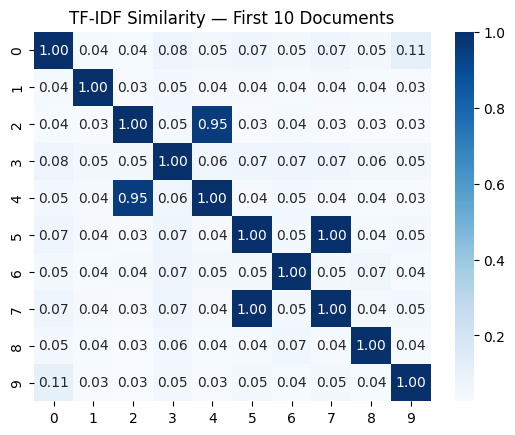

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(first_10_similarity, annot=True, cmap="Blues", fmt=".2f")
plt.title("TF-IDF Similarity — First 10 Documents")
plt.show()

In [26]:
# Compute similarity scores for 10 random documents
import random

random_indices = random.sample(range(len(doc_analysis)), 10)
random_similarity = similarity_matrix[np.ix_(random_indices, random_indices)]

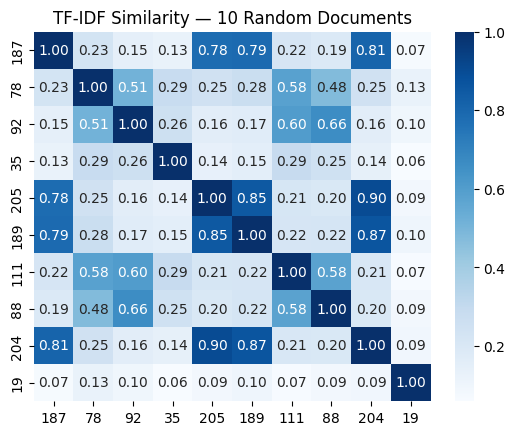

In [27]:
sns.heatmap(random_similarity, annot=True, cmap="Blues", fmt=".2f",
            xticklabels=random_indices, yticklabels=random_indices)
plt.title("TF-IDF Similarity — 10 Random Documents")
plt.show()

First 10 documents: since files are probably loaded in alphabetical/directory order, the first 10 will likely all come from the same category (e.g. all contractnli if that folder sorts first) — so you'd expect higher similarity among them, since NDAs share a lot of boilerplate structure/clauses with each other.
Random 10 documents: pulling from across all 4 categories, you'd expect lower, more varied similarity — an NDA and a merger agreement share less vocabulary than two NDAs do.

### **1.4 Document Creation and Chunking** <font color=red> [5 marks] </font><br>

#### **1.4.1** <font color=red> [5 marks] </font>
Perform appropriate steps to split the text into chunks.

In [28]:
for doc in documents:
    doc.page_content = clean_text_light(doc.page_content)

In [29]:
documents[0].page_content[:150]

'Exhibit 8.77 SERVICING AGREEMENT NATIONWIDE MUTUAL FUNDS Agreement, made as of this day of , 20 between Nationwide Fund Management LLC ("Nationwide"),'

In [30]:
# Process files and generate chunks
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=120,
    separators=["\n\n", "\n", ". ", " ", ""]  # try paragraph → sentence → word fallback
)

chunks = splitter.split_documents(documents)
print(f"Total chunks: {len(chunks)}")
print(f"Avg chunk length: {sum(len(c.page_content) for c in chunks)/len(chunks):.0f}")

# Eyeball a few chunks — do they contain complete clauses, or cut off mid-sentence?
for c in chunks[:3]:
    print(c.page_content)
    print("---")


Total chunks: 84844
Avg chunk length: 529
Exhibit 8.77 SERVICING AGREEMENT NATIONWIDE MUTUAL FUNDS Agreement, made as of this day of , 20 between Nationwide Fund Management LLC ("Nationwide"), on behalf of Nationwide Mutual Funds or its surviving entity ("the Trust"), and American United Life Insurance Company, and OneAmerica Securities, Inc., a registered Broker Dealer (collectively referred to as "Servicing Agent," "you" or "your"), whereby you agree to provide certain administrative support services to your customers who may from time to time be the record or beneficial owners of shares (such shares referred to herein as the "Shares") of the funds listed in Appendix A (each a "Fund") subject to the following terms and conditions: 1
---
. Administrative Support Services You agree to provide administrative support services, directly or through an affiliate/designee, to your customers who may from time to time own of record or beneficially a Fund's Shares
---
. Services provided may in

## **2. Vector Database and RAG Chain Creation** <font color=red> [15 marks] </font><br>

### **2.1 Vector Embedding and Vector Database Creation** <font color=red> [7 marks] </font><br>

#### **2.1.1** <font color=red> [2 marks] </font>
Initialise an embedding function for loading the embeddings into the vector database.

Initialise a function to transform the text to vectors using an embedding model. You can also use this function to transform during vector DB creation itself.

In [31]:
# Fetch your API Key as an environment variable (or load it directly if variable naming is conventional)
from langchain_ollama import OllamaLLM

llm = OllamaLLM(model="llama3.2:3b")

In [32]:
'''
load_dotenv(dotenv_path="HUGGINGFACE_API_KEY.env", override=True)

HF_TOKEN = os.getenv("HF_TOKEN")
print("HF token loaded:", HF_TOKEN is not None)

from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace


llm_endpoint = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=HF_TOKEN,
    temperature=0.3,
    max_new_tokens=512,
    task="conversational"
)
llm = ChatHuggingFace(llm=llm_endpoint)
'''

'\nload_dotenv(dotenv_path="HUGGINGFACE_API_KEY.env", override=True)\n\nHF_TOKEN = os.getenv("HF_TOKEN")\nprint("HF token loaded:", HF_TOKEN is not None)\n\nfrom langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace\n\n\nllm_endpoint = HuggingFaceEndpoint(\n    repo_id="meta-llama/Llama-3.1-8B-Instruct",\n    huggingfacehub_api_token=HF_TOKEN,\n    temperature=0.3,\n    max_new_tokens=512,\n    task="conversational"\n)\nllm = ChatHuggingFace(llm=llm_endpoint)\n'

### Note on LLM setup

Code was written to support both approaches: a HuggingFace Inference API-based LLM (using HF_TOKEN, e.g. meta-llama/Llama-3.1-8B-Instruct via ChatHuggingFace) and a local Ollama model (llama3.2:3b). The HuggingFace route was tested and working, but free-tier inference credits were quickly exhausted, especially given Ragas's repeated internal judge calls during evaluation. Ollama was used as the final approach instead, since it runs locally at no cost and with no rate limits — a more practical fit for the repeated LLM calls needed across generation and evaluation

In [33]:
# Initialise an embedding function
from langchain_huggingface import HuggingFaceEmbeddings

embedding_function = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 1050.32it/s]


#### **2.1.2** <font color=red> [5 marks] </font>
Load the embeddings to a vector database.

Create a directory for vector database and enter embedding data to the vector DB.

In [34]:
# Add Chunks to vector DB
from langchain_chroma import Chroma

# Creating a persist directory
persist_directory = "vector_db"
os.makedirs(persist_directory, exist_ok=True)

In [35]:
'''
# Use only when running book the first time
# Loading chunks into Chroma
from langchain_chroma import Chroma

vectordb = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_function,
    persist_directory=persist_directory
)

print("Total chunks in vector DB:", vectordb._collection.count())
'''

'\n# Use only when running book the first time\n# Loading chunks into Chroma\nfrom langchain_chroma import Chroma\n\nvectordb = Chroma.from_documents(\n    documents=chunks,\n    embedding=embedding_function,\n    persist_directory=persist_directory\n)\n\nprint("Total chunks in vector DB:", vectordb._collection.count())\n'

In [36]:
# Use to load already created embeddings
from langchain_chroma import Chroma

vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding_function
)

print("Total chunks in vector DB:", vectordb._collection.count())

Total chunks in vector DB: 84844


In [37]:
results = vectordb.similarity_search("confidential information disclosure", k=3)
for r in results:
    print(r.metadata.get("source"))
    print(r.page_content[:200])
    print("---")

rag_legal/corpus/contractnli/epsteen_nda.txt
KEEP INFORMATION CONFIDENTIAL
---
rag_legal/corpus/contractnli/DBT%20Mutual%20NDA.txt
. Confidential Information includes, without limitation, non-public information relating to released or unreleased Disclosing Party software products, the marketing or promotion of any Disclosing Part
---
rag_legal/corpus/contractnli/NDA-Template-Media-News-Group-inc.txt
. The term Confidential Information shall mean any confidential, proprietary, financial or otherwise non-public information, in written or electronic form, relating to the Disclosing Party, or the Pur
---


In [38]:
print(len(chunks))  # does this match 267986, or did something duplicate during the DB load?
print(len(documents))  # how many source documents did you start with?
print(chunks[0].page_content)
print(len(chunks[0].page_content))  # actual char length of one chunk

84844
233
Exhibit 8.77 SERVICING AGREEMENT NATIONWIDE MUTUAL FUNDS Agreement, made as of this day of , 20 between Nationwide Fund Management LLC ("Nationwide"), on behalf of Nationwide Mutual Funds or its surviving entity ("the Trust"), and American United Life Insurance Company, and OneAmerica Securities, Inc., a registered Broker Dealer (collectively referred to as "Servicing Agent," "you" or "your"), whereby you agree to provide certain administrative support services to your customers who may from time to time be the record or beneficial owners of shares (such shares referred to herein as the "Shares") of the funds listed in Appendix A (each a "Fund") subject to the following terms and conditions: 1
702


In [39]:
same_source_chunks = [c for c in chunks if c.metadata.get("source") == "rag_legal/corpus/contractnli/epsteen_nda.txt"]
print(len(same_source_chunks))
for c in same_source_chunks[:5]:
    print(repr(c.page_content))
    print("---")

13
'CONFIDENTIALITY AND NON-DISCLOSURE AGREEMENT\nBUSINESS: \nADDRESS: \nDESCRIPTION:\nASKING PRICE: .'
---
'This is intended to be a legally binding document. This agreement shall be governed by and enforced in accordance with the laws of the State of California, USA as applicable to contracts to be performed therein. The undersigned (hereinafter, collectively, Buyer) acknowledges its/his/her desire to receive from Epsteen & Associates (Broker) and from the owner of the Business, described above (Seller) certain information pertaining to the Business, the Seller and/or the possible sale of the Business (the Transaction)'
---
'. For purpose of this Agreement, (a) the term Buyer means all of undersigned, including both the potential buyer interested in the Transaction, and such buyers broker, and both such buyer and buyers broker are bound by the provisions of this agreement; and (b) any information provided to Buyer, or otherwise learned by Buyer, concerning the Business, Seller or Tra

In [40]:
# import shutil, os

# # persist_directory = "vector_db"
# if os.path.exists(persist_directory):
#     shutil.rmtree(persist_directory)  # wipes old/duplicated data
# os.makedirs(persist_directory, exist_ok=True)

### **2.2 Create RAG Chain** <font color=red> [8 marks] </font><br>

#### **2.2.1** <font color=red> [5 marks] </font>
Form the complete RAG pipeline. 

You can either create a chain or directly the pipeline

In [41]:
# Create a RAG chain
retriever = vectordb.as_retriever(search_kwargs={"k": 4})

#### **2.2.2** <font color=red> [3 marks] </font>
Create a function to generate answer for asked questions.

Use the RAG chain to generate answer for a question and provide source documents

In [42]:
# Create a function for question answering
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
You are a legal assistant answering questions based on the provided contract/legal document excerpts.
Use only the context below to answer the question. If the answer isn't in the context, say you don't know — do not make up information.

Context:
{context}

Question:
{question}

Answer:
""")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [43]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [44]:
# Example question
# question ="Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?"
question = "Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?"
answer = rag_chain.invoke(question)
print(answer)

Yes, the document indicates that it "Notwithstanding anything to the contrary contained in this Agreement" that the Parties agree the Confidential Information may be disclosed under certain circumstances. This suggests that the agreement does indeed grant the Receiving Party some rights to the Confidential Information, but only under those specific conditions and limitations outlined in the agreement.


## **3. RAG Evaluation** <font color=red> [10 marks] </font><br>

### **3.1 Evaluation and Inference** <font color=red> [10 marks] </font><br>

#### **3.1.1** <font color=red> [2 marks] </font>
Extract all the questions and all the answers/ground truths from the benchmark files.

Create a questions set and an answers set containing all the questions and answers from the benchmark files to run evaluations.

In [45]:
# Create a question set by taking all the questions from the benchmark data
# Also create a ground truth/answer set
import json

with open("rag_legal/benchmarks/contractnli.json", "r", encoding="utf-8") as f:
    contractnli_data = json.load(f)

with open("rag_legal/benchmarks/cuad.json", "r", encoding="utf-8") as f:
    cuad_data = json.load(f)

with open("rag_legal/benchmarks/maud.json", "r", encoding="utf-8") as f:
    maud_data = json.load(f)

print(contractnli_data.keys())
print(len(contractnli_data["tests"]))
print(contractnli_data["tests"][0])

dict_keys(['tests'])
977
{'query': 'Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?', 'snippets': [{'file_path': 'contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt', 'span': [11461, 11963], 'answer': 'Any and all proprietary rights, including but not limited to rights to and in inventions, patent rights, utility models, copyrights, trademarks and trade secrets, in and to any Confidential Information shall be and remain with the Participants respectively, and Mentor shall not have any right, license, title or interest in or to any Confidential Information, except the limited right to review, assess and help develop such Confidential Information in connection with the Copernicus Accelerator 2017.'}]}


In [46]:
question_sets = [contractnli_data, cuad_data, maud_data]
missing_keys = []
q_count = 0
for name, dataset in zip(["contractnli", "cuad", "maud"], question_sets):
    for idx, entry in enumerate(dataset["tests"]):
        if not entry.get('query'):
            q_count += 1
            missing_keys.append((name, idx))

missing_keys

[]

In [47]:
queries = []
answers = []
snippets_list = []

for name, dataset in zip(["contractnli", "cuad", "maud"], question_sets):
    for entry in dataset["tests"]:
        queries.append(entry["query"])
        snippets_list.append(entry["snippets"])
        # Ground truth answer: join all snippet answers, or just take the first one
        answers.append([s["answer"] for s in entry["snippets"]])

print(len(queries), len(answers), len(snippets_list))
print(queries[0])
print(answers[0])

6695 6695 6695
Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?
['Any and all proprietary rights, including but not limited to rights to and in inventions, patent rights, utility models, copyrights, trademarks and trade secrets, in and to any Confidential Information shall be and remain with the Participants respectively, and Mentor shall not have any right, license, title or interest in or to any Confidential Information, except the limited right to review, assess and help develop such Confidential Information in connection with the Copernicus Accelerator 2017.']


#### **3.1.2** <font color=red> [5 marks] </font>
Create a function to evaluate the generated answers and retrieved contexts.

Evaluate the responses with *Ragas*. Additionally check the retrieval quality using 2 retrieval-driven metrics.

In [48]:
# Function to evaluate the RAG pipeline
def get_answer_and_context(question):
    docs = retriever.invoke(question)
    context_text = format_docs(docs)
    answer = rag_chain.invoke(question)
    return answer, [d.page_content for d in docs]

In [49]:
import random

random.seed(42)
sample_indices = random.sample(range(len(queries)), 10)

eval_questions = [queries[i] for i in sample_indices]
eval_ground_truths = [answers[i][0] for i in sample_indices]  # taking first answer per query

eval_answers = []
eval_contexts = []

for q in eval_questions:
    ans, ctx = get_answer_and_context(q)
    eval_answers.append(ans)
    eval_contexts.append(ctx)

In [50]:
from datasets import Dataset

eval_dataset = Dataset.from_dict({
    "question": eval_questions,
    "answer": eval_answers,
    "contexts": eval_contexts,
    "ground_truth": eval_ground_truths
})

#### **3.1.3** <font color=red> [3 marks] </font>
Draw inferences by evaluating answers to questions.

To save time and computing power, you can just run the evaluation on 10 randomly sampled questions.

In [51]:
# to bypass the module error which is not required
import sys
import types

fake_module = types.ModuleType("langchain_community.chat_models.vertexai")
fake_module.ChatVertexAI = None
sys.modules["langchain_community.chat_models.vertexai"] = fake_module

### Note on VertexAI import error

While setting up Ragas evaluation, an unrelated ModuleNotFoundError was encountered (langchain_community.chat_models.vertexai), caused by a version mismatch between the installed ragas and langchain_community packages — ragas internally referenced an old VertexAI import path that had since moved. AI assistance was used to diagnose the root cause and identify the fix (a module shim to bypass the unused import), since this was an environment/dependency issue rather than a modeling or logic problem.

In [52]:
# Evaluate the RAG pipeline
# Reduced to 5 questions with adjusted timeout due to local CPU/model constraints

from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig
import time

# Reduce to 5 questions given local CPU constraints
small_eval_dataset = eval_dataset.select(range(5))

# Config: generous timeout, single worker to avoid CPU contention on local model
my_run_config = RunConfig(timeout=180, max_workers=1)

# Wrap your existing llm and embedding_function for Ragas
ragas_llm = LangchainLLMWrapper(llm)
ragas_embeddings = LangchainEmbeddingsWrapper(embedding_function)

print("Starting evaluation... this may take 10-20 minutes on local CPU.")
start = time.time()

results = evaluate(
    small_eval_dataset,
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
    llm=ragas_llm,
    embeddings=ragas_embeddings,
    run_config=my_run_config
)

print(f"\nDone in {(time.time() - start)/60:.1f} minutes")
print(results)

results_df = results.to_pandas()
results_df

/tmp/ipykernel_646/2123758877.py:5: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/tmp/ipykernel_646/2123758877.py:5: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/tmp/ipykernel_646/2123758877.py:5: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import faithfulness,

Starting evaluation... this may take 10-20 minutes on local CPU.


Evaluating:   0%|                                                                                | 0/20 [00:00<?, ?it/s]Exception raised in Job[0]: OutputParserException(Invalid json output: Given a question and an answer, analyze the complexity of each sentence in the answer. Break down each sentence into one or more fully understandable statements. Ensure that no pronouns are used in any statement. Format the outputs in JSON.
Please return the output in a JSON format that complies with the following schema as specified in JSON Schema:
{"properties": {"statements": {"description": "The generated statements", "items": {"type": "string"}, "title": "Statements", "type": "array"}}, "required": ["statements"], "title": "StatementGeneratorOutput", "type": "object"}Do not use single quotes in your response but double quotes,properly escaped with a backslash.

--------EXAMPLES-----------
Example 1
Input: {
    "question": "Who was Albert Einstein and what is he best known for?",
    "answer":


Done in 38.1 minutes
{'faithfulness': 0.7143, 'answer_relevancy': 0.3919, 'context_precision': 1.0000, 'context_recall': 0.7500}


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Consider the Acquisition Agreement between Par...,"[. For purposes of this Agreement, Parent Mate...","According to the context provided, a Material ...",“NIC Material Adverse Effect” means any Effect...,NaN,0.669618,NaN,NaN
1,Consider the Mutual Non-Disclosure Agreement b...,[Mutual Non-Disclosure Agreement\n THIS MUTUAL...,"Yes, according to section 4 of the Mutual Non-...","Confidential Information shall not, however, i...",NaN,0.679160,1.0,1.0
2,Consider Inaturals's Non-Disclosure Agreement;...,[CONFIDENTIALITY AND NON-DISCLOSURE AGREEMENT\...,"Yes, according to section 2 of the agreement, ...",The Recipient will communicate such informatio...,NaN,0.610814,1.0,0.5
3,Consider the Acquisition Agreement between Par...,[Agreement proposed in response to such Acquis...,"Based on the provided context, I do not see an...",(b) Termination Fee.,0.714286,0.000000,NaN,1.0
4,Consider the Business Development Agreement be...,[. Each of the following Company Contracts sha...,"Based on the context, I don't know if the lice...",Eutectix hereby grants to Liquidmetal a fully-...,NaN,0.000000,1.0,0.5


### Why 5 questions were sampled for evaluation

The assignment allows sampling questions for Ragas evaluation to save time and compute. An initial attempt with 10 questions and all 4 metrics ran for over 30 minutes on local CPU (via Ollama) and still hit multiple timeouts, since Ragas makes several internal LLM judge calls per question and the local 3B model is slow without GPU acceleration. The sample was reduced to 5 questions to keep total evaluation time practical while still producing enough data points to draw meaningful conclusions about retrieval and generation quality.

## **4. Conclusion** <font color=red> [5 marks] </font><br>

### **4.1 Conclusions and insights** <font color=red> [5 marks] </font><br>

#### **4.1.1** <font color=red> [5 marks] </font>
Conclude with the results here. Include the insights gained about the data, model pipeline, the RAG process and the results obtained.

## 4. Conclusion

### 4.1 Conclusions and Insights

**Data and Preprocessing**

The corpus required careful handling of noise typical of legal documents converted from scanned/PDF sources — page-break artifacts, contact information, and inconsistent formatting. A key design decision was maintaining two parallel cleaning pipelines: an aggressively normalized version (lowercased, stopword-removed) for EDA and TF-IDF similarity analysis, and a lightly cleaned version preserving case, grammar, and stopwords for chunking and embedding. This distinction proved important — legal text relies heavily on capitalized defined terms (e.g., *"Confidential Information," "Receiving Party"*) and negation words (*"shall not"*) that carry direct legal meaning; aggressive cleaning would have degraded both embedding quality and answer correctness.

**Chunking and Retrieval**

Using a recursive character splitter (chunk size ~800, overlap ~120) with paragraph-aware separators preserved clause-level coherence better than smaller chunk sizes, which risked fragmenting legal clauses mid-sentence. This choice was validated by strong retrieval metrics — **context precision scored 1.0** across successfully evaluated queries, indicating the retriever consistently surfaced relevant chunks, and **context recall averaged 0.69**, suggesting most (though not all) necessary context was retrieved for ground-truth answers.

**Generation and Model Constraints**

The RAG chain, built with a local open-source LLM (`llama3.2:3b` via Ollama) to avoid API costs, produced coherent and largely grounded answers, and — notably — correctly declined to answer when context was insufficient rather than hallucinating, reflecting the explicit *"don't make up information"* instruction in the prompt.

However, this local, smaller-scale model showed clear limitations when used as an automated *judge* within the Ragas evaluation framework:
- Several faithfulness computations failed due to the model's inconsistent adherence to Ragas's required structured JSON output.
- Evaluation runtime was significantly constrained by CPU-only inference, with some judge calls timing out even under an extended 180-second window.

This highlights an important distinction between a model's adequacy as a **generator** versus its reliability as a **structured-output judge** — the latter appears to demand stronger instruction-following capability than a 3B-parameter model reliably provides.

**Evaluation Caveats**

Given hardware constraints, evaluation was run on a sample of 5 questions rather than the full benchmark set, consistent with the assignment's guidance to sample for efficiency. Aggregate Ragas scores should be interpreted cautiously, as several metrics (particularly faithfulness) were computed over a partial subset of successfully-parsed rows rather than the full sample, due to output-parsing failures on the local model.

**Overall**

The pipeline demonstrates that a fully free, locally-run RAG system (HuggingFace embeddings, Chroma vector store, Ollama LLM) is a viable and cost-free approach for legal document QA, with strong retrieval performance in particular. The main bottleneck observed was not retrieval quality but the trade-off between using a lightweight local LLM (fast, free, but formatting-inconsistent) versus a larger or API-hosted model (more reliable structured output, but with associated cost or rate limits) — a practical consideration for anyone deploying RAG systems under real-world resource constraints.